# Homework: PCA for Feature Extraction in Spike Sorting

<a target="_blank" href="https://colab.research.google.com/github/ANDA-NI-2026/ANDA-Day3-Dimensionality-Reduction/blob/main/01_homework_pca_for_spike_sorting/01_solutions.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

Modern devices for extracellular electrophysiology (like Neuropixels) can acquire massive amounts of data. However this can make spike sorting (the process of assigning recorded spikes to individual neurons) tricky because the number of dimensions to consider is very large. Principal component analysis (PCA) provides a principled way of selecting a few relevant dimensions that carry the most information. This makes spike sorting on large multi-electrode recordings much more tractable.

The in-session notebooks will go into more detail on how PCA actually works. The point of this notebook is to help you build intuition for applying PCA and introduce spike sorting as an important use case for dimensionality reduction. You'll work with tetrode recordings and use PCA to extract the most relevant dimensions and transform the data. Finally, you'll see how we can apply a clustering algorithm to find spikes that belong to the same neuron.

## Setup

### Import Libraries

Import the modules required for this notebook

In [55]:
import numpy as np
from matplotlib import pyplot as plt
from sklearn.decomposition import PCA
from sklearn.mixture import GaussianMixture

### Download Data

Download the data required for this session

In [85]:
import requests
from pathlib import Path

url = "https://uni-bonn.sciebo.de/s/aFQ1gcUbOHRDEtP"
fname = Path("spike_waveforms.npy")
tmp_name = fname.with_suffix(".download")

print("Downloading Data ...")
response = requests.get(f"{url}/download", timeout=60)
response.raise_for_status()
tmp_name.write_bytes(response.content)

# Refuse to save server error pages or other non-NPY content as the dataset.
with open(tmp_name, "rb") as file:
    magic = file.read(6)

if magic != b"\x93NUMPY":
    tmp_name.unlink(missing_ok=True)
    raise ValueError("Downloaded file is not a valid .npy file. The server may have returned an error page instead.")

tmp_name.replace(fname)
print("Done!")

Done!


## Extracting Waveform Features with PCA

This section will introduce you to PCA using the implementation from the Scikit-learn package. When we apply PCA, we have to decide the number of components we want to keep. Each component explains a certain amount of variance in the data and usually a few components are enough to explain most of the variance. We can plot the variance explained by each component and their sum to get a quick idea about how many components are required to represent the data accurately.

### Code Reference

| Code | Description |
|---|---|
| `waveforms.shape` | Get the dimensions (shape) of the `waveforms` NumPy array. |
| `X = waveforms[:, :, 0]` | Select all data from the first channel (index 0) of the 3D `waveforms` array. |
| `pca = PCA(n_components=n)` | Create a Principal Component Analysis (PCA) object to find `n` components. |
| `X_transformed = pca.fit_transform(X)` | Fit the PCA model to data `X` and apply dimensionality reduction. |
| `pca.explained_variance_ratio_` | Get the fraction of variance explained by each principal component. |
| `plt.plot(data)` | Plot the values in the `data` array as a line graph. |
| `np.cumsum(array)` | Calculate the cumulative sum of the elements in an array. |
| `sum(array[:n])` | Calculate the sum of the first `n` elements of an array. |

### Exercises

Run the cell below to load the data. The data contains 19482 spike waveforms recorded at 4 channels. Each waveform is 30 samples long.

In [57]:
waveforms = np.load("spike_waveforms.npy")
waveforms.shape

(19482, 30, 4)

Run the code below to plot the first 10 waveforms for every channel. As you can see, the latency and amplitude of the spikes differs between channels. This information can be exploited by spike-sorting algorithms.

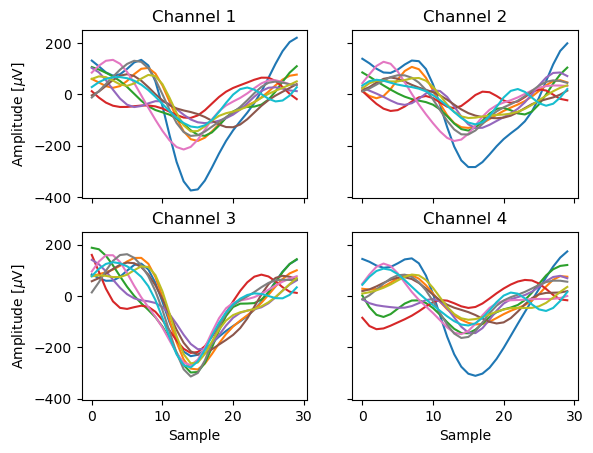

In [58]:
X = waveforms[:10, :, :]
fig, ax = plt.subplots(2, 2, sharex=True, sharey=True)

ax[0, 0].plot(X[:, :, 0].T);
ax[0, 1].plot(X[:, :, 1].T);
ax[1, 0].plot(X[:, :, 2].T);
ax[1, 1].plot(X[:, :, 3].T);

ax[0, 0].set(ylabel="Amplitude [$\\mu$V]", title="Channel 1")
ax[0, 1].set(title="Channel 2")
ax[1, 0].set(ylabel="Amplitude [$\\mu$V]", xlabel="Sample", title="Channel 3")
ax[1, 1].set(xlabel="Sample", title="Channel 4");

**Example**: Use `PCA` with `n_components=5` to transform the spike waveforms recorded at the first channel.

In [59]:
X = waveforms[:, :, 0]
pca = PCA(n_components=5)
X_transformed = pca.fit_transform(X)
X.shape

(19482, 30)

**Exercise**: Use `PCA` with `n_components=7` to transform the spike waveforms recorded at the first channel. Compare the `.shape` of the original and the transformed data.

In [60]:
X = waveforms[:, :, 0]
pca = PCA(n_components=7)
X_transformed = pca.fit_transform(X)
print(X.shape, X_transformed.shape)

(19482, 30) (19482, 7)


**Exercise**: Use `PCA` with `n_components=15` to transform the spike waveforms recorded at the first channel. Compare the `.shape` of the original and the transformed data.

In [61]:
X = waveforms[:, :, 0]
pca = PCA(n_components=15)
X_transformed = pca.fit_transform(X)
print(X.shape, X_transformed.shape)

(19482, 30) (19482, 15)


**Exercise**: What error message do you observe when you try to apply `PCA` with `n_components=41`?

In [62]:
pca = PCA(n_components=41)
X_transformed = pca.fit_transform(X)

ValueError: n_components=41 must be between 0 and min(n_samples, n_features)=30 with svd_solver='covariance_eigh'

**Exercise**: Plot the ratio of variance explained by the PCA components (i.e. `pca.explained_variance_ratio_`)

In [63]:
pca = PCA(n_components=15)
X_transformed = pca.fit_transform(X)

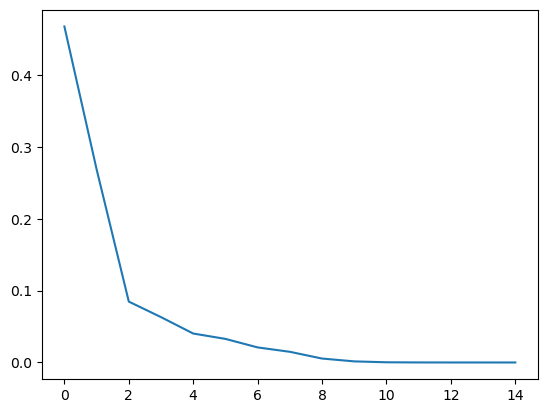

In [64]:
plt.plot(pca.explained_variance_ratio_);

**Exercise**: Compute the cumulative ratio of explained variance using `np.cumsum()` and plot it

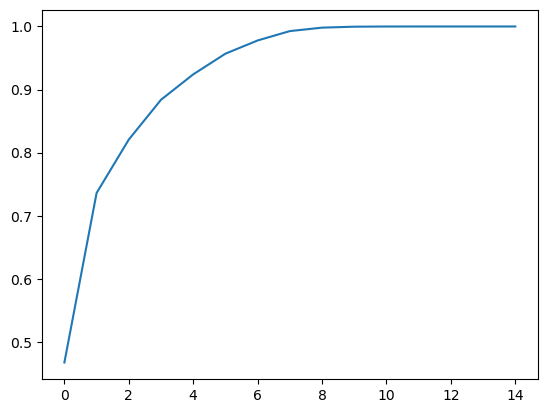

In [65]:
plt.plot(np.cumsum(pca.explained_variance_ratio_));

**Exercise**: What ratio of the variance is explained by the first three components (i.e. what is the `sum()` of the first three elements of `.explained_variance_ratio_`?) and how many components are required to account for over 99% of variance?

In [66]:
print(sum(pca.explained_variance_ratio_[:3]))
print(sum(pca.explained_variance_ratio_[:8]))

0.820759476628594
0.9926894524591845


## Visualizing Principal Components

PCA is a powerful technique, but its components can be abstract. To build intuition, it's helpful to visualize what these components represent in relation to the original data. In this section, we will plot the principal components themselves to see what waveform shapes they capture. These components are directions of variation in centered data space and are shown in arbitrary units, not as actual recorded waveforms in microvolts. We will also use the inverse PCA transformation to reconstruct waveforms from a limited number of components, which demonstrates how much information is retained.

### Code Reference

| Code | Description |
|---|---|
| `pca.components_` | Access the principal components (eigenvectors) from a fitted PCA model. |
| `X_inverse = pca.inverse_transform(X_transformed)` | Transform data from PCA space back to its original space. |
| `plt.subplot(rows, cols, index)` | Create a subplot within a grid at a given `index`. |
| `X.T` | Transpose the matrix `X`, swapping its rows and columns. |
| `plt.xlabel("label")` | Set the label for the x-axis of a plot. |
| `plt.ylabel("label")` | Set the label for the y-axis of a plot. |

---

#### **Exercises**

**Example**: Fit a `PCA` with `n_components=3` to the waveforms recorded at the first channel and plot the first component, along with the first 100 recorded waveforms.

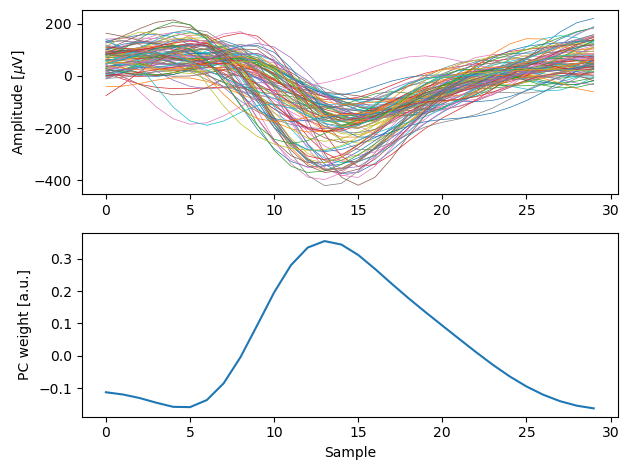

In [67]:
X = waveforms[:, :, 0]
pca = PCA(n_components=3)
X_transformed = pca.fit_transform(X)

plt.subplot(2, 1, 1)
plt.plot(X[:100].T, linewidth=0.5)
plt.ylabel("Amplitude [$\\mu$V]")

plt.subplot(2, 1, 2)
plt.plot(pca.components_[0])
plt.xlabel("Sample")
plt.ylabel("PC weight [a.u.]")
plt.tight_layout()

**Exercise**: Plot the second and third principal components along with the first 100 waveforms recorded at the first channel.

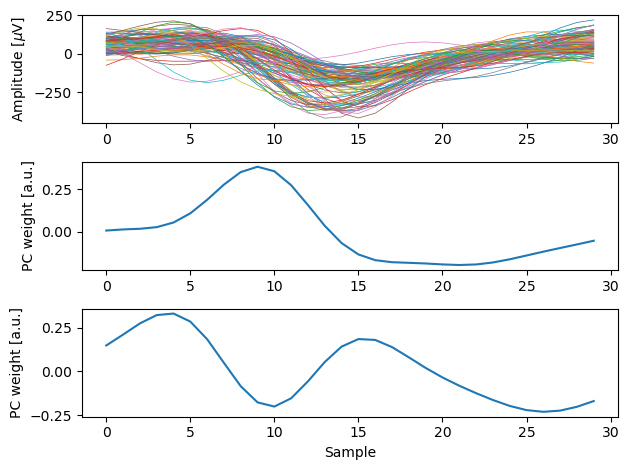

In [68]:
plt.subplot(3, 1, 1)
plt.plot(X[:100].T, linewidth=0.5)
plt.ylabel("Amplitude [$\\mu$V]")

plt.subplot(3, 1, 2)
plt.plot(pca.components_[1])
plt.ylabel("PC weight [a.u.]")

plt.subplot(3, 1, 3)
plt.plot(pca.components_[2])
plt.xlabel("Sample")
plt.ylabel("PC weight [a.u.]")
plt.tight_layout()

**Example**: Compute a `PCA` with `n_components=1` for the waveforms recorded at the first channel and transform the data. Then, compute the `.inverse_transform()` of the transformed data and plot the result of the inverse transformation `X_inverse` along with the original data `X` for the first spike.

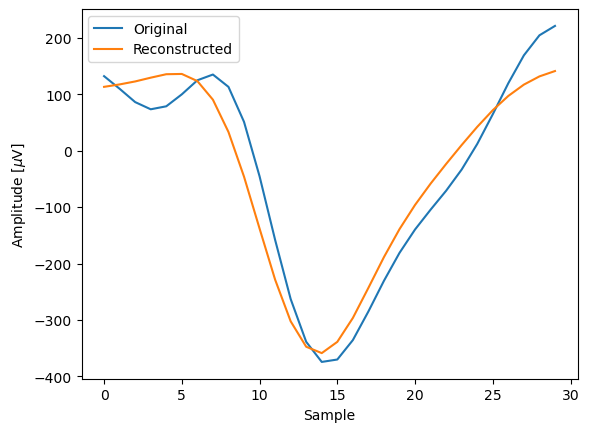

In [69]:
X = waveforms[:, :, 0]
pca = PCA(n_components=1)
X_transformed = pca.fit_transform(X)
X_inverse = pca.inverse_transform(X_transformed)

plt.plot(X[0], label="Original")
plt.plot(X_inverse[0], label="Reconstructed")
plt.xlabel("Sample")
plt.ylabel("Amplitude [$\\mu$V]")
plt.legend();

**Exercise**: Plot the original data `X` and the result of the inverse transformation `X_inverse` for the 7th spike.

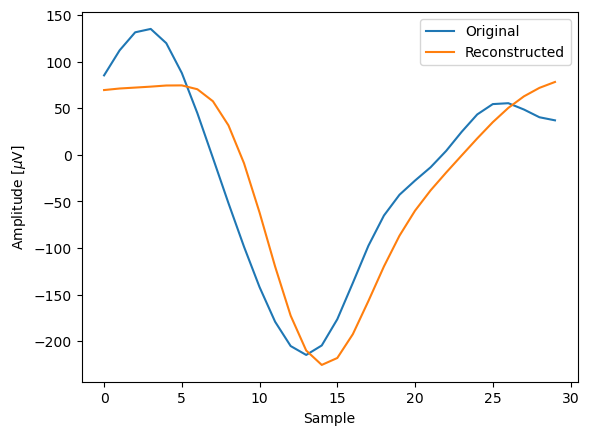

In [70]:
plt.plot(X[6], label="Original")
plt.plot(X_inverse[6], label="Reconstructed")
plt.xlabel("Sample")
plt.ylabel("Amplitude [$\\mu$V]")
plt.legend();

**Exercise**: Re-compute the `PCA` and increase the number of `n_components`, then `fit_transform` and `inverse_transform` the data. How many components do you need before the original data `X` and the reconstruction `X_inverse` look nearly indistinguishable? How does this compare to the cumulative explained variance from the previous section?

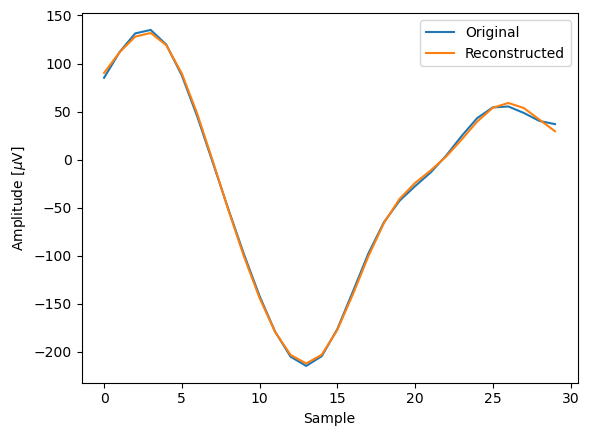

In [71]:
X = waveforms[:, :, 0]
pca = PCA(n_components=9)
X_transformed = pca.fit_transform(X)
X_inverse = pca.inverse_transform(X_transformed)
plt.plot(X[6], label="Original")
plt.plot(X_inverse[6], label="Reconstructed")
plt.xlabel("Sample")
plt.ylabel("Amplitude [$\\mu$V]")
plt.legend();

## Visualizing Waveforms in PCA Space

In the previous sections, we used PCA to describe each spike waveform with only a few numbers instead of the full waveform across time. We can now use these PCA scores as features for visualization. If spikes from different neurons have distinct waveform shapes across the tetrode channels, they may form separate groups in this low-dimensional PCA feature space.

Here, we compute PCA separately for each channel and keep the first three components per channel. We then compare the first PCA score across different channels to see whether the spikes form visually separable clusters. Each point in the plots represents one detected spike.

### Code Reference

| Code | Description |
|---|---|
| `plt.scatter(x, y, s=1)` | Create a 2D scatterplot with small points. |
| `waveforms_transformed[:, 0, 0]` | Select the 1st PCA score for all spikes at channel 1. |
| `fig = plt.figure(figsize=(7, 6))` | Create a new figure for a 3D plot. |
| `ax = fig.add_subplot(projection="3d")` | Create a 3D plotting axis. |
| `ax.scatter(x, y, z, s=1)` | Create a 3D scatterplot. |
| `ax.set_xlabel("label")` | Set the x-axis label. |
| `ax.set_ylabel("label")` | Set the y-axis label. |
| `ax.set_zlabel("label")` | Set the z-axis label. |
| `ax.view_init(elev=20, azim=80)` | Set the vertical and horizontal viewing angle of a 3D plot. |

### Exercises

Run the code below to compute PCA with 3 components on the waveforms recorded on every channel and store the transformed data in a new array `waveforms_transformed`.

In [72]:
n_components = 3
pca = PCA(n_components=n_components)
n_spikes = waveforms.shape[0]
n_channels = waveforms.shape[-1]
waveforms_transformed = np.zeros((n_spikes, n_components, n_channels))
for i in range(n_channels):
    X = waveforms[:, :, i]
    X_transformed = pca.fit_transform(X)
    waveforms_transformed[:, :, i] = X_transformed

**Example**: Plot the 1st PCA score at channel 1 against the 1st PCA score at channel 2 for all spikes (each spike is one dot).

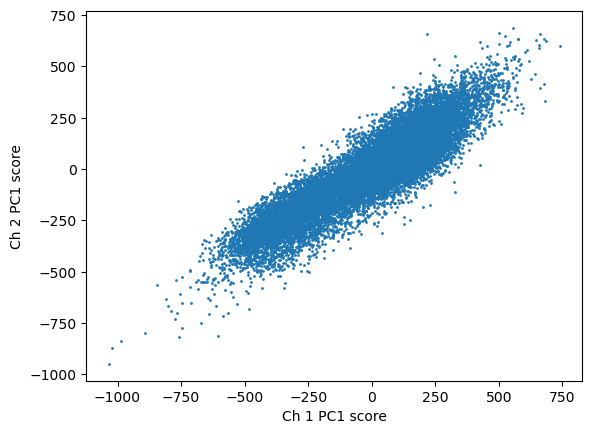

In [73]:
plt.scatter(waveforms_transformed[:, 0, 0], waveforms_transformed[:, 0, 1], s=1)
plt.xlabel("Ch 1 PC1 score")
plt.ylabel("Ch 2 PC1 score");

**Exercise**: Plot the 1st PCA score at channel 1 against the 1st PCA score at channel 3 for all spikes. Can you visually identify clusters that the individual spikes may fall into?

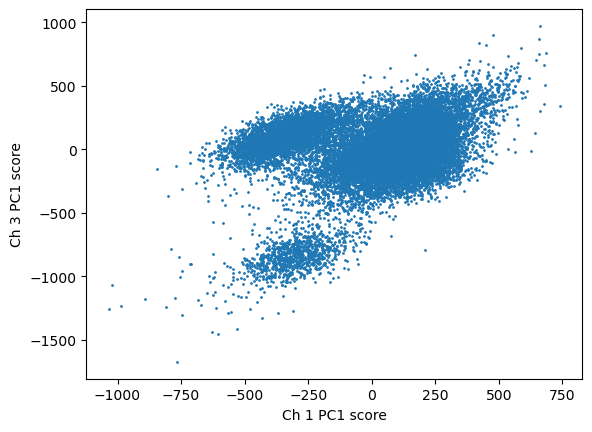

In [74]:
plt.scatter(waveforms_transformed[:, 0, 0], waveforms_transformed[:, 0, 2], s=1)
plt.xlabel("Ch 1 PC1 score")
plt.ylabel("Ch 3 PC1 score");

**Exercise**: Plot the 1st PCA score at channel 3 against the 1st PCA score at channel 4 for all spikes. Can you visually identify clusters that the individual spikes may fall into?

Text(0, 0.5, 'Ch 4 PC1 score')

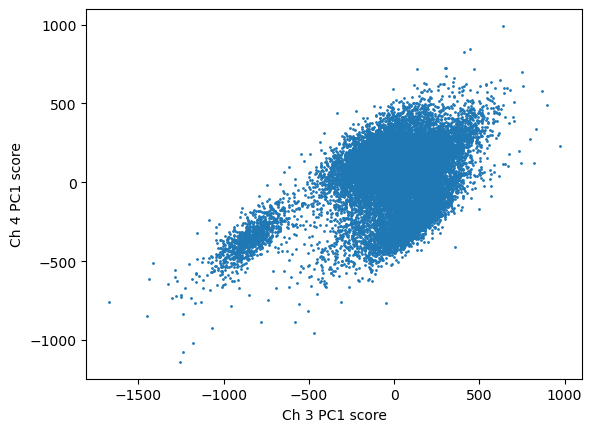

In [75]:
plt.scatter(waveforms_transformed[:, 0, 2], waveforms_transformed[:, 0, 3], s=1)
plt.xlabel("Ch 3 PC1 score")
plt.ylabel("Ch 4 PC1 score")

**Exercise**: Plot the 1st PCA score at channel 2 against the 1st PCA score at channel 3 for all spikes. Can you visually identify clusters that the individual spikes may fall into?

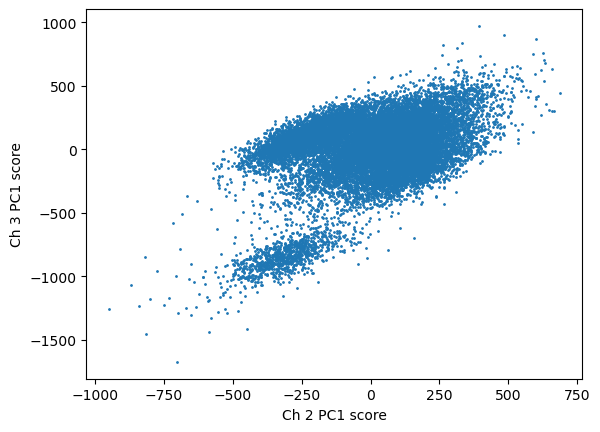

In [76]:
plt.scatter(waveforms_transformed[:, 0, 1], waveforms_transformed[:, 0, 2], s=1)
plt.xlabel("Ch 2 PC1 score")
plt.ylabel("Ch 3 PC1 score");

**Example**: Create a 3D scatterplot with the 1st PCA score at channels 1, 2, and 3.

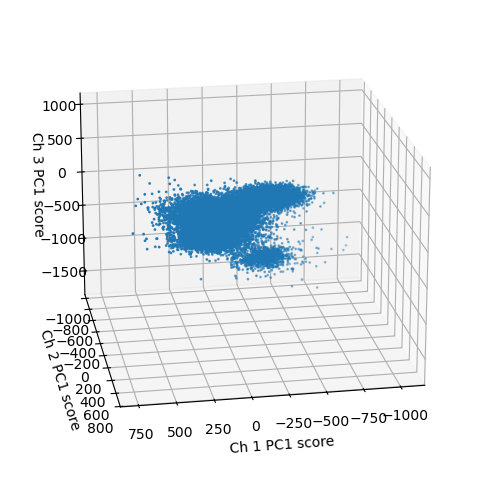

In [77]:
fig = plt.figure(figsize=(7, 6))
ax = fig.add_subplot(projection="3d")

scatter = ax.scatter(
    waveforms_transformed[:, 0, 0],
    waveforms_transformed[:, 0, 1],
    waveforms_transformed[:, 0, 2],
    s=1,
)

ax.set_xlabel("Ch 1 PC1 score")
ax.set_ylabel("Ch 2 PC1 score")
ax.set_zlabel("Ch 3 PC1 score")
ax.view_init(elev=20, azim=80)

**Exercise**: Create a 3D scatterplot with the 1st PCA score at channels 1, 3, and 4. Adjust the viewing angle with `ax.view_init(elev, azim)` so that you can see the clusters.

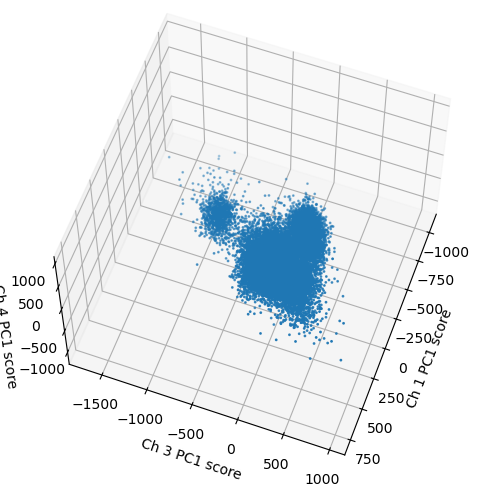

In [78]:
fig = plt.figure(figsize=(7, 6))
ax = fig.add_subplot(projection="3d")

scatter = ax.scatter(
    waveforms_transformed[:, 0, 0],
    waveforms_transformed[:, 0, 2],
    waveforms_transformed[:, 0, 3],
    s=1,
)

ax.set_xlabel("Ch 1 PC1 score")
ax.set_ylabel("Ch 3 PC1 score")
ax.set_zlabel("Ch 4 PC1 score")
ax.view_init(elev=60, azim=20)

## Clustering Spikes with Gaussian Mixture Models

In the previous section, we could already see clusters by plotting a few PCA scores against each other. However, those plots only show two or three dimensions at a time, while our full feature representation contains several PCA scores across multiple channels. To cluster spikes using all of these features at once, we need an algorithm that can work in higher-dimensional space.

A Gaussian Mixture Model (GMM) is one way to do this. It models the data as a mixture of several Gaussian-shaped clusters and assigns each spike to the cluster that best explains its PCA features. Applying the GMM itself is a demonstration rather than the main teaching objective of the notebook: the goal is to see how the PCA features can be passed into a clustering algorithm and then visualized back in PCA space.

### Code Reference

| Code | Description |
|---|---|
| `plt.scatter(X[:, 0, 0], X[:, 0, 1], s=1, color="gray")` | Plot all spikes in gray using the 1st PCA score from channels 1 and 2. |
| `X = waveforms_transformed[spike_labels == cluster]` | Select only the spikes assigned to one cluster. |
| `plt.scatter(X[:, 0, 0], X[:, 0, 1], s=5, label=cluster)` | Highlight one cluster in a 2D scatterplot. |
| `ax.scatter(X[:, 0, 0], X[:, 0, 1], X[:, 0, 2], s=3, label=cluster)` | Highlight one cluster in a 3D scatterplot. |
| `plt.legend()` | Show the cluster labels in the plot legend. |

### Applying a Gaussian Mixture Model

Run the cell below to reshape `waveforms_transformed` into a 2D array and then apply a `GaussianMixture` model with `n_components=13` to fit 13 Gaussian clusters to the data.

**Note**: How to find the optimal number of clusters is outside the scope of this notebook, but for this data, 13 clusters is optimal according to the Bayesian Information Criterion (BIC).

In [79]:
X = waveforms_transformed.reshape(-1, n_components * n_channels, order="F")
gmm = GaussianMixture(
    n_components=13,
    random_state=7
)
gmm.fit(X)

,"n_components n_components: int, default=1The number of mixture components.",13
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given to the method chosen to initialize theparameters (see `init_params`).In addition, it controls the generation of random samples from thefitted distribution (see the method `sample`).Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",7
,"covariance_type covariance_type: {'full', 'tied', 'diag', 'spherical'}, default='full'String describing the type of covariance parameters to use.Must be one of:- 'full': each component has its own general covariance matrix.- 'tied': all components share the same general covariance matrix.- 'diag': each component has its own diagonal covariance matrix.- 'spherical': each component has its own single variance.For an example of using `covariance_type`, refer to:ref:`sphx_glr_auto_examples_mixture_plot_gmm_selection.py`.",'full'
,"tol tol: float, default=1e-3The convergence threshold. EM iterations will stop when thelower bound average gain is below this threshold.",0.001
,"reg_covar reg_covar: float, default=1e-6Non-negative regularization added to the diagonal of covariance.Allows to assure that the covariance matrices are all positive.",1e-06
,"max_iter max_iter: int, default=100The number of EM iterations to perform.",100
,"n_init n_init: int, default=1The number of initializations to perform. The best results are kept.",1
,"init_params init_params: {'kmeans', 'k-means++', 'random', 'random_from_data'}, default='kmeans'The method used to initialize the weights, the means and theprecisions.String must be one of:- 'kmeans' : responsibilities are initialized using kmeans.- 'k-means++' : use the k-means++ method to initialize.- 'random' : responsibilities are initialized randomly.- 'random_from_data' : initial means are randomly selected data points... versionchanged:: v1.1 `init_params` now accepts 'random_from_data' and 'k-means++' as initialization methods.",'kmeans'
,"weights_init weights_init: array-like of shape (n_components, ), default=NoneThe user-provided initial weights.If it is None, weights are initialized using the `init_params` method.",None
,"means_init means_init: array-like of shape (n_components, n_features), default=NoneThe user-provided initial means,If it is None, means are initialized using the `init_params` method.",None
,"precisions_init precisions_init: array-like, default=NoneThe user-provided initial precisions (inverse of the covariancematrices).If it is None, precisions are initialized using the 'init_params'method.The shape depends on 'covariance_type':: (n_components,) if 'spherical', (n_features, n_features) if 'tied', (n_components, n_features) if 'diag', (n_components, n_features, n_features) if 'full'",None


Now we can use the fitted model to assign every spike to a cluster.

In [80]:
spike_labels = gmm.predict(X)
spike_labels

array([ 2, 10,  9, ...,  2,  2, 11], shape=(19482,))

First, inspect how many spikes were assigned to each cluster.

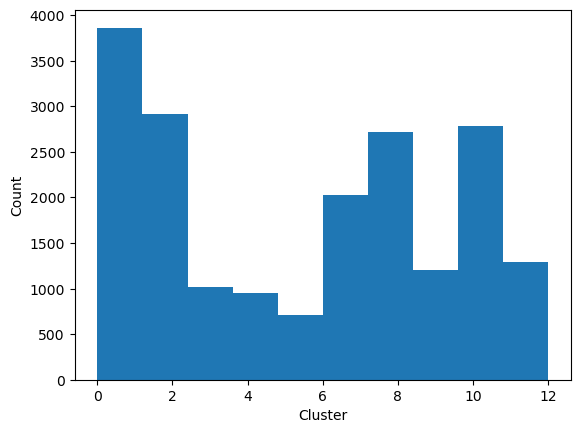

In [81]:
plt.hist(spike_labels)
plt.xlabel("Cluster")
plt.ylabel("Count");

**Exercise**: Plot the 1st PCA score at channel 1 against the 1st PCA score at channel 2 for all spikes and highlight the spikes that belong to clusters 0 through 5.

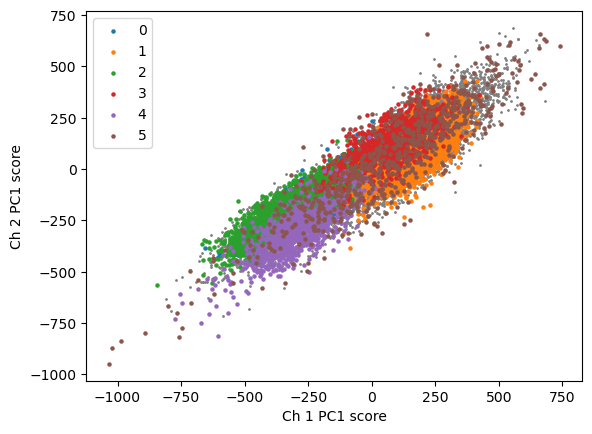

In [82]:
clusters = [0, 1, 2, 3, 4, 5]
X = waveforms_transformed
plt.scatter(X[:, 0, 0], X[:, 0, 1], s=1, color="gray")
for cluster in clusters:
    X = waveforms_transformed[spike_labels == cluster]
    plt.scatter(X[:, 0, 0], X[:, 0, 1], s=5, label=cluster)
    plt.xlabel("Ch 1 PC1 score")
    plt.ylabel("Ch 2 PC1 score")
plt.legend();

**Exercise**: Plot the 1st PCA score at channel 2 against the 1st PCA score at channel 3 for all spikes and highlight the spikes that belong to clusters 0 through 5.

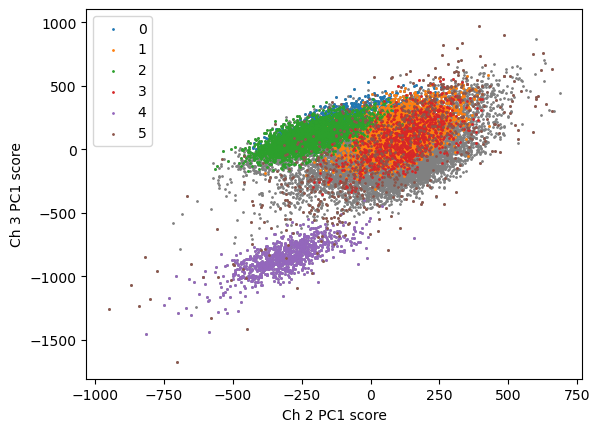

In [83]:
clusters = [0, 1, 2, 3, 4, 5]
X = waveforms_transformed
plt.scatter(X[:, 0, 1], X[:, 0, 2], s=1, color="gray")
for cluster in clusters:
    X = waveforms_transformed[spike_labels == cluster]
    plt.scatter(X[:, 0, 1], X[:, 0, 2], s=1, label=cluster)
    plt.xlabel("Ch 2 PC1 score")
    plt.ylabel("Ch 3 PC1 score")
plt.legend();

**Bonus**: Create a 3D scatterplot with the 1st PCA score at channels 1, 2, and 3 and highlight the points that belong to clusters 0 through 5. Adjust the viewing angle with `ax.view_init(elev, azim)` so that you can see the clusters.

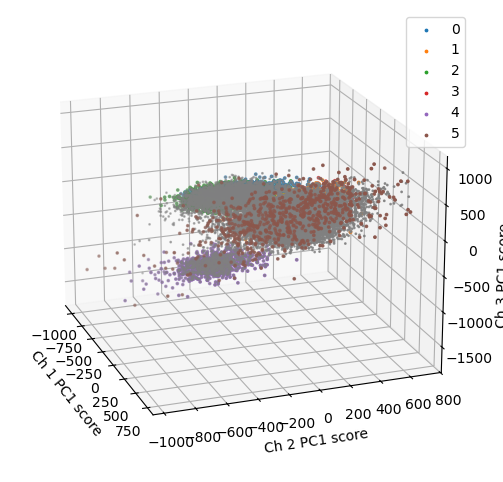

In [84]:
clusters = [0, 1, 2, 3, 4, 5]
X = waveforms_transformed
fig = plt.figure(figsize=(7, 6))
ax = fig.add_subplot(projection="3d")

scatter = ax.scatter(X[:, 0, 0], X[:, 0, 1], X[:, 0, 2], s=1, color="gray")

for cluster in clusters:
    X = waveforms_transformed[spike_labels == cluster]
    scatter = ax.scatter(X[:, 0, 0], X[:, 0, 1], X[:, 0, 2], s=3, label=cluster)

ax.set_xlabel("Ch 1 PC1 score")
ax.set_ylabel("Ch 2 PC1 score")
ax.set_zlabel("Ch 3 PC1 score")
ax.legend()
ax.view_init(elev=20, azim=-20)